# Modelo de Ising — Algoritmo de Metropolis-Hastings

Implementação da classe `IsingModel` com condições de fronteira periódicas,  
`J = 1`, `h = 0`, `kb = 1`, rede 2D quadrada de lado `L`, spins iniciais `+1`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import CubicSpline, RegularGridInterpolator

J  = 1
h  = 0
kb = 1
rnd = np.random.default_rng(seed=1)


# ── Classe do Modelo de Ising ────────────────────────────────────────────────
class IsingModel:

    def __init__(self, L, T):
        self.L = L
        self.T = T
        self.spins = np.ones((L, L))
        self.energies       = []
        self.magnetizations = []

    def calc_ener_spin(self, i, j) -> float:
        L     = self.L
        own   = self.spins[i, j]
        right = self.spins[i,          (j + 1) % L]
        down  = self.spins[(i + 1) % L,  j        ]
        return -J * own * (right + down) - h * own

    def calc_ener(self) -> float:
        right = np.roll(self.spins, -1, axis=1)
        down  = np.roll(self.spins, -1, axis=0)
        return -J * np.sum(self.spins * (right + down)) - h * np.sum(self.spins)

    def calc_mag(self) -> float:
        return J * np.sum(self.spins) / self.L**2

    def flip(self, i, j) -> None:
        self.spins[i, j] *= -1

    def iter_monte_carlo(self, n_iter):
        L = self.L
        self.energies       = np.empty(n_iter + 1)
        self.magnetizations = np.empty(n_iter + 1)

        E   = self.calc_ener()
        mag = self.calc_mag()
        self.energies[0]       = E
        self.magnetizations[0] = mag

        i_vals = rnd.integers(0, L,     size=n_iter)
        j_vals = rnd.integers(0, L,     size=n_iter)
        u_vals = rnd.uniform (0.0, 1.0, size=n_iter)

        for k in tqdm(range(n_iter), desc=f"L={L:6d}, T={self.T:8.4f}"):
            i, j, u = i_vals[k], j_vals[k], u_vals[k]
            own = self.spins[i, j]

            sumviz = (self.spins[i,          (j + 1) % L] +
                      self.spins[i,          (j - 1) % L] +
                      self.spins[(i + 1) % L,  j        ] +
                      self.spins[(i - 1) % L,  j        ])

            delta = 2.0 * own * (J * sumviz + h)

            if delta < 0 or np.exp(-delta / (kb * self.T)) > u:
                self.flip(i, j)
                E   += delta
                mag -= 2.0 * J * own / L**2

            self.energies[k + 1]       = E
            self.magnetizations[k + 1] = mag

    @property
    def energy(self):
        return np.array(self.energies)

    @property
    def magnetization(self):
        return np.array(self.magnetizations)


---
## Exercício 1 — Tempo de Termalização

### 1(a)

Para cada combinação de $L \in \{16, 32, 64, 128\}$ e $T \in \{1, 2, 3, 4\}$,
corre a simulação e representa a energia por spin $e \equiv E/L^2$
em função do número de iteração $N$.

O número de iterações é $n_\mathrm{iter} = n_\mathrm{sweeps} \cdot L^2$
para que o número de varrimentos seja idêntico em todos os tamanhos.

L=   128, T=  4.0000: 100%|██████████| 163840/163840 [00:00<00:00, 950579.41it/s]


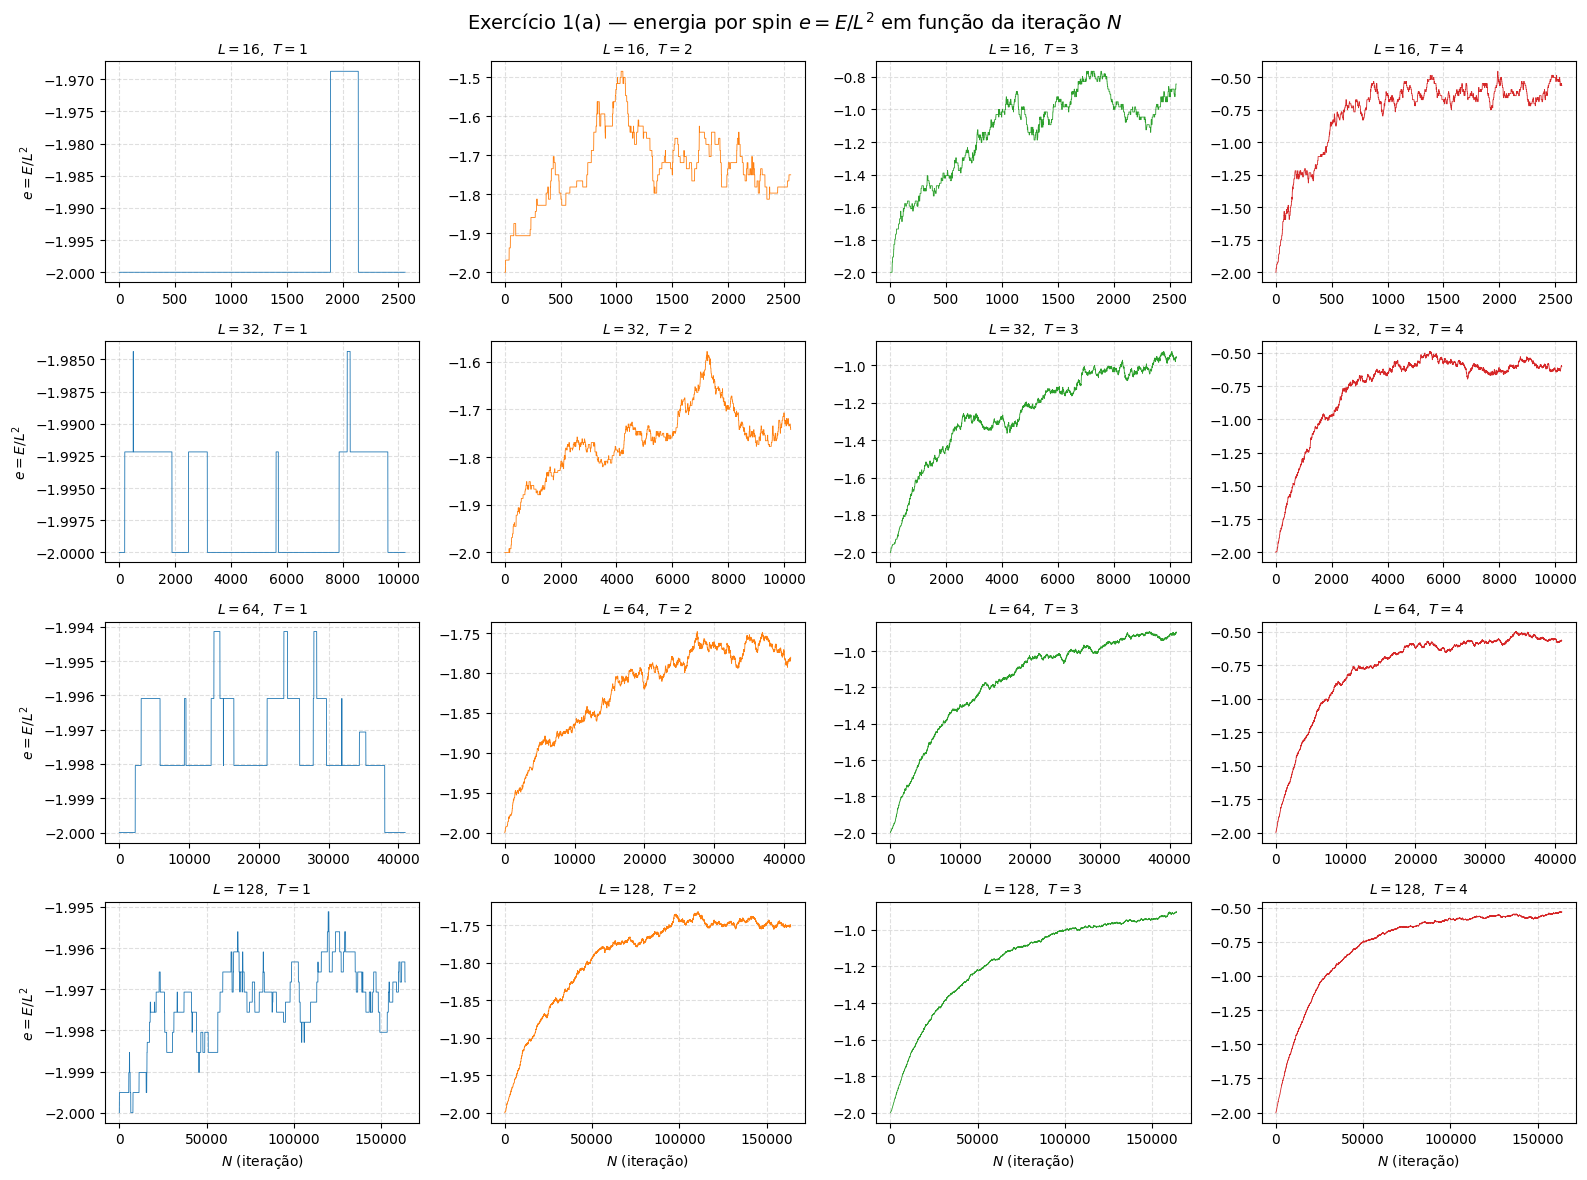

In [2]:
L_values = [16, 32, 64, 128]
T_values = [1, 2, 3, 4]
n_sweeps = 10

results = {}

for L in L_values:
    n_iter = n_sweeps * L**2
    for T in T_values:
        model = IsingModel(L, T)
        model.iter_monte_carlo(n_iter)
        results[(L, T)] = model.energy / L**2

# ── Gráficos: grelha 4×4, linhas = L, colunas = T ────────────────────────────
fig, axes = plt.subplots(len(L_values), len(T_values), figsize=(16, 12))
fig.suptitle(
    r"Exercício 1(a) — energia por spin $e = E/L^2$ em função da iteração $N$",
    fontsize=14
)
cores = ["C0", "C1", "C2", "C3"]

for row, L in enumerate(L_values):
    for col, T in enumerate(T_values):
        ax = axes[row, col]
        e  = results[(L, T)]
        N  = np.arange(len(e))
        ax.plot(N, e, lw=0.6, color=cores[col])
        ax.set_title(f"$L = {L}$,  $T = {T}$", fontsize=10)
        ax.grid(True, ls="--", alpha=0.4)
        if row == len(L_values) - 1:
            ax.set_xlabel("$N$ (iteração)")
        if col == 0:
            ax.set_ylabel(r"$e = E/L^2$")

plt.tight_layout()
plt.show()


### 1(b)

Fit da energia por spin à função de termalização:

$$e(N) = e_f + (e_0 - e_f)\,e^{-N/\tau_\mathrm{term}}$$

com $e_0 = -2$ fixo (estado inicial). O fit determina $e_f(L,T)$ e $\tau_\mathrm{term}(L,T)$.

**Nota sobre a caso $T = 1$:**
A $T = 1$ (muito abaixo de $T_c \approx 2.27$), o estado inicial todo `+1` já é
praticamente o estado de equilíbrio: $e_0 \approx e_f \approx -2$. O termo
$(e_0 - e_f)$ é então $\approx 0$ e $\tau$ deixa de ser identificável pelos dados
— qualquer valor de $\tau$ produz a mesma curva. Nesta região, fisicamente,
$\tau_\mathrm{term} \to 0$ (o sistema não precisa de termalizar).

Para tornar este facto explícito, a tabela inclui:
- as colunas brutas $e_f$ e $\tau$ devolvidas pelo `curve_fit`;
- uma coluna `status` que marca como `unreliable` os fits em que (i) $e_f$ encosta no
  limite, (ii) $\sigma_\tau/\tau > 0.3$, ou (iii) $\tau > N_{\max}$;
- uma coluna $\tau_\mathrm{use}$ que é igual a $\tau$ para os fits ok e a $1$ para
  os fits degenerados/não fiáveis (valor sentinela; corresponde a $\tau \to 0$,
  saturado em 1 para evitar problemas numéricos posteriores).

É $\tau_\mathrm{use}$ que é usado no exercício 2 para definir $N_\mathrm{term}=4\tau_\mathrm{use}$.

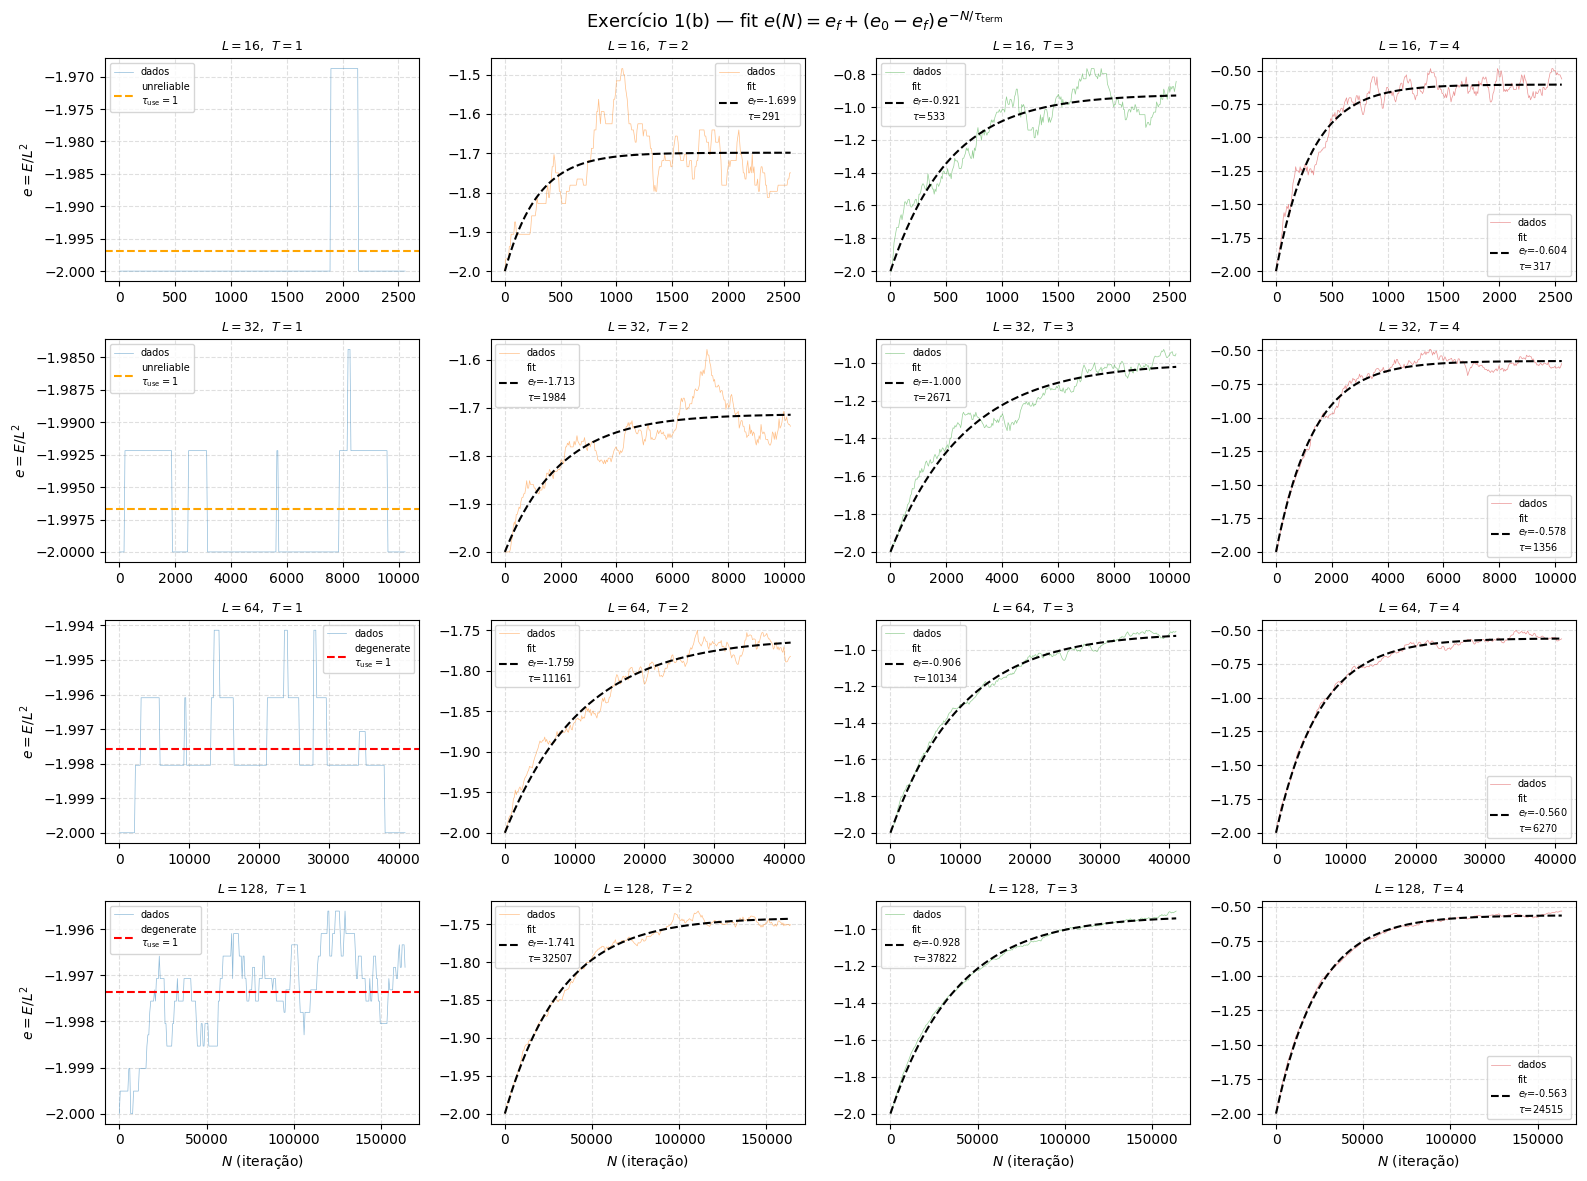


   L    T         ef      ±σ_ef       τ (raw)          ±σ_τ       status     τ_use
──────────────────────────────────────────────────────────────────────────────────────
  16    1     0.5000   840.5880      888758.9   299156084.8   unreliable       1.0
  16    2    -1.6986     0.0041         291.4          21.4           ok     291.4
  16    3    -0.9211     0.0077         532.8          13.9           ok     532.8
  16    4    -0.6042     0.0042         316.8           4.9           ok     316.8
  32    1    -1.9967     0.0002          80.4          98.2   unreliable       1.0
  32    2    -1.7127     0.0031        1983.9          81.2           ok    1983.9
  32    3    -1.0004     0.0061        2671.4          51.1           ok    2671.4
  32    4    -0.5784     0.0026        1356.1          12.0           ok    1356.1
  64    1    -1.9976     0.0014       (plana)             –   degenerate       1.0
  64    2    -1.7591     0.0012       11161.1         173.4           ok   11161.1

In [3]:
def therm_model(N, ef, tau):
    e0 = -2.0
    return ef + (e0 - ef) * np.exp(-N / tau)

# Parâmetros das verificações de fiabilidade
RANGE_THRESHOLD       = 0.01
REL_UNCERTAINTY_LIMIT = 0.3
EF_BOUND_TOL          = 1e-3

fit_params = {}   # (L,T) -> [ef, tau]   (valores brutos do curve_fit)
fit_errors = {}   # (L,T) -> [σ_ef, σ_τ] (idem)
fit_status = {}   # (L,T) -> 'ok' | 'degenerate' | 'unreliable' | 'failed'
tau_use    = {}   # (L,T) -> valor de τ a usar no exercício 2

for L in L_values:
    for T in T_values:

        e = results[(L, T)]
        N = np.arange(len(e), dtype=float)

        step  = max(1, len(e) // 500)
        e_sub = e[::step]
        N_sub = N[::step]

        # ── Caso 1: curva essencialmente plana — fit não é possível ────────
        if (e_sub.max() - e_sub.min()) < RANGE_THRESHOLD:
            fit_params[(L, T)] = np.array([float(e_sub.mean()), np.nan])
            fit_errors[(L, T)] = np.array([float(e_sub.std()),  np.nan])
            fit_status[(L, T)] = 'degenerate'
            tau_use   [(L, T)] = 1.0
            continue

        # ── Caso 2: tentar o fit ───────────────────────────────────────────
        n_tail = max(1, len(e_sub) // 10)
        ef_p0  = float(e_sub[-n_tail:].mean())
        tau_p0 = float(L**2)

        try:
            popt, pcov = curve_fit(
                therm_model, N_sub, e_sub,
                p0     = [ef_p0, tau_p0],
                bounds = ([-2.5, 1.0], [0.5, np.inf]),
                maxfev = 10000,
            )
            perr = np.sqrt(np.diag(pcov))
        except (RuntimeError, ValueError):
            fit_params[(L, T)] = np.full(2, np.nan)
            fit_errors[(L, T)] = np.full(2, np.nan)
            fit_status[(L, T)] = 'failed'
            tau_use   [(L, T)] = 1.0
            continue

        # ── Caso 3: verificar fiabilidade do fit ───────────────────────────
        ef, tau         = popt
        sigma_ef, s_tau = perr
        N_max           = float(N_sub[-1])

        ef_at_bound      = (abs(ef - 0.5)  < EF_BOUND_TOL or
                            abs(ef + 2.5)  < EF_BOUND_TOL)
        huge_uncertainty = s_tau > abs(tau) * REL_UNCERTAINTY_LIMIT
        tau_unobservable = tau > N_max

        fit_params[(L, T)] = popt
        fit_errors[(L, T)] = perr

        if ef_at_bound or huge_uncertainty or tau_unobservable:
            fit_status[(L, T)] = 'unreliable'
            tau_use   [(L, T)] = 1.0
        else:
            fit_status[(L, T)] = 'ok'
            tau_use   [(L, T)] = float(tau)

# ── Gráficos: dados + fit ────────────────────────────────────────────────────
fig, axes = plt.subplots(len(L_values), len(T_values), figsize=(16, 12))
fig.suptitle(
    r"Exercício 1(b) — fit $e(N)=e_f+(e_0-e_f)\,e^{-N/\tau_\mathrm{term}}$",
    fontsize=13
)
status_colors = {'ok': 'k', 'degenerate': 'red', 'unreliable': 'orange', 'failed': 'gray'}

for row, L in enumerate(L_values):
    for col, T in enumerate(T_values):
        ax = axes[row, col]
        e  = results[(L, T)]
        N  = np.arange(len(e))

        step = max(1, len(e) // 300)
        ax.plot(N[::step], e[::step], lw=0.5, color=f"C{col}", alpha=0.5, label="dados")

        ef, tau = fit_params[(L, T)]
        status  = fit_status[(L, T)]
        N_fit   = np.linspace(0, N[-1], 500)
        cor     = status_colors[status]

        if status == 'ok':
            ax.plot(N_fit, therm_model(N_fit, ef, tau),
                    color=cor, lw=1.5, ls="--",
                    label=f"fit\n$e_f$={ef:.3f}\n$\\tau$={tau:.0f}")
        elif status in ('degenerate', 'unreliable'):
            # mostra a constante e_f = média dos dados (τ_use = 1 ↔ horizontal)
            ax.axhline(float(np.mean(e)), color=cor, lw=1.5, ls="--",
                       label=f"{status}\n$\\tau_\\mathrm{{use}}=1$")

        ax.set_title(f"$L={L}$,  $T={T}$", fontsize=9)
        ax.legend(fontsize=7, loc="best")
        ax.grid(True, ls="--", alpha=0.4)
        if row == len(L_values) - 1:
            ax.set_xlabel("$N$ (iteração)")
        if col == 0:
            ax.set_ylabel(r"$e = E/L^2$")

plt.tight_layout()
plt.show()

# ── Tabela ───────────────────────────────────────────────────────────────────
print(f"\n{'L':>4}  {'T':>3}  {'ef':>9}  {'±σ_ef':>9}  {'τ (raw)':>12}  {'±σ_τ':>12}  {'status':>11}  {'τ_use':>8}")
print("─" * 86)
for L in L_values:
    for T in T_values:
        ef,  tau  = fit_params[(L, T)]
        sef, stau = fit_errors[(L, T)]
        status   = fit_status[(L, T)]
        tu       = tau_use[(L, T)]
        tau_str  = f"{tau:>12.1f}" if not np.isnan(tau) else f"{'(plana)':>12s}"
        stau_str = f"{stau:>12.1f}" if not np.isnan(stau) else f"{'–':>12s}"
        print(f"{L:>4}  {T:>3}  {ef:>9.4f}  {sef:>9.4f}  {tau_str}  {stau_str}  {status:>11s}  {tu:>8.1f}")


### 1(c)

Representação de $\tau_\mathrm{term}(L, T)$ e construção de um interpolador com
`RegularGridInterpolator` (método cúbico). Para a interpolação usa-se $\tau_\mathrm{use}$
(τ = 1 nos pontos não fiáveis), de modo a não propagar valores absurdos.

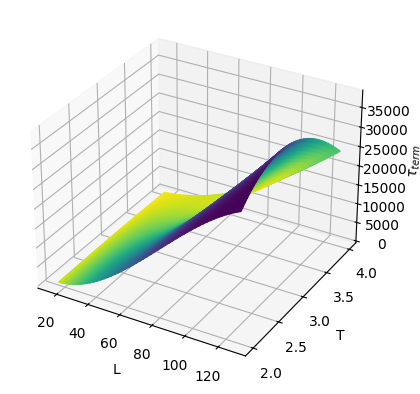

In [4]:
L_vals = np.array(L_values)
T_vals = np.array(T_values)

tau_grid = np.array([
    [tau_use[(L, T)] for T in T_vals]
    for L in L_vals
])

# Para o erro: usa σ_τ nos fits ok, 0 para degenerate/unreliable
err_grid = np.array([
    [fit_errors[(L, T)][1] if fit_status[(L, T)] == 'ok' else 0.0
     for T in T_vals]
    for L in L_vals
])

interp_tau = RegularGridInterpolator((L_vals, T_vals), tau_grid, method="cubic")
interp_err = RegularGridInterpolator((L_vals, T_vals), err_grid, method="cubic")

def plot_region(L_min=None, L_max=None, T_min=None, T_max=None, dim=200):
    L_min = L_vals.min() if L_min is None else L_min
    L_max = L_vals.max() if L_max is None else L_max
    T_min = T_vals.min() if T_min is None else T_min
    T_max = T_vals.max() if T_max is None else T_max

    L_f = np.linspace(L_min, L_max, dim)
    T_f = np.linspace(T_min, T_max, dim)
    Lg, Tg = np.meshgrid(L_f, T_f, indexing="ij")
    pts = np.column_stack([Lg.ravel(), Tg.ravel()])

    tau_f = interp_tau(pts).reshape(Lg.shape)
    err_f = interp_err(pts).reshape(Lg.shape)

    err_norm = err_f / (np.nanmax(err_f) + 1e-12)
    colors = plt.cm.viridis(1 - err_norm)
    colors[..., -1] = 1.0

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(Lg, Tg, tau_f, facecolors=colors, shade=False)
    ax.set_xlabel("L"); ax.set_ylabel("T"); ax.set_zlabel(r"$\tau_{term}$")
    plt.show()

plot_region(16, 128, 2, 4)


---
## Exercício 2 — Determinação da Temperatura Crítica

### 2(a)

Variando a temperatura de $T_{\min}=1$ a $T_{\max}=4$ em passos de $\Delta T=0.2$,
fazem-se $10^6$ medições da energia e magnetização para cada $T$ e cada
$L \in \{16, 32, 64, 128\}$.

Notas importantes:
- A magnetização é tomada em **valor absoluto** ($\langle |m| \rangle$). Para $T < T_c$
  o sistema finito pode flippar o sinal global de $M$ durante a simulação, levando
  $\langle m \rangle \to 0$ mesmo na fase ordenada; $\langle |m| \rangle$ é o parâmetro
  de ordem fisicamente correcto.
- Guardam-se também $\langle E \rangle$ e $\langle E^2 \rangle$ (energia **total**)
  para o cálculo da capacidade calorífica em 2(c) por flutuações.
- O tempo de termalização $\tau_\mathrm{use}$ vem do exercício 1, via o interpolador.
  É depois usado como $N_\mathrm{term} = 4\tau_\mathrm{use}$.

L=   128, T=  4.0000: 100%|██████████| 1000000/1000000 [00:01<00:00, 870027.45it/s]


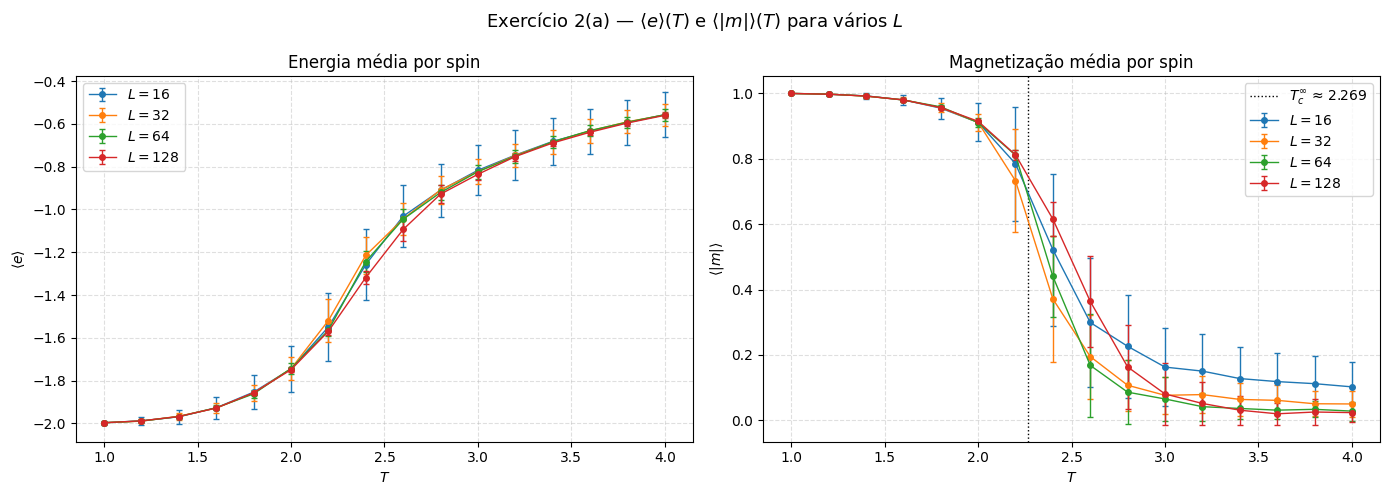

In [5]:
L_values_2a = [16, 32, 64, 128]
T_values_2a = np.arange(1.0, 4.0 + 1e-9, 0.2)
n_meas      = 1_000_000

e_mean    = np.zeros((len(L_values_2a), len(T_values_2a)))
e_std     = np.zeros_like(e_mean)
e_sq_mean = np.zeros_like(e_mean)
m_mean    = np.zeros_like(e_mean)
m_std     = np.zeros_like(e_mean)
E_mean    = np.zeros_like(e_mean)   # energia total para 2(c)
E_sq_mean = np.zeros_like(e_mean)   # idem

for iL, L in enumerate(L_values_2a):
    for iT, T in enumerate(T_values_2a):

        tau_estimado = float(interp_tau([[L, T]])[0])
        if np.isnan(tau_estimado) or tau_estimado < 1.0:
            tau_estimado = 1.0
        n_term = max(1, int(4 * tau_estimado))

        model = IsingModel(L, T)
        model.iter_monte_carlo(n_term)   # termalização
        model.iter_monte_carlo(n_meas)   # medição

        e_arr = model.energy / L**2
        m_arr = model.magnetization

        e_mean   [iL, iT] = e_arr.mean()
        e_std    [iL, iT] = e_arr.std()
        e_sq_mean[iL, iT] = (e_arr**2).mean()

        E_mean   [iL, iT] = model.energy.mean()
        E_sq_mean[iL, iT] = (model.energy**2).mean()

        abs_m          = np.abs(m_arr)
        m_mean[iL, iT] = abs_m.mean()
        m_std [iL, iT] = abs_m.std()

# ── Gráficos ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    r"Exercício 2(a) — $\langle e \rangle(T)$ e $\langle |m| \rangle(T)$ para vários $L$",
    fontsize=13
)
cores = ["C0", "C1", "C2", "C3"]

for iL, L in enumerate(L_values_2a):
    axes[0].errorbar(T_values_2a, e_mean[iL], yerr=e_std[iL],
                     marker="o", ms=4, lw=1, capsize=2,
                     color=cores[iL], label=f"$L = {L}$")
    axes[1].errorbar(T_values_2a, m_mean[iL], yerr=m_std[iL],
                     marker="o", ms=4, lw=1, capsize=2,
                     color=cores[iL], label=f"$L = {L}$")

Tc_inf = 2.0 / np.log(1.0 + np.sqrt(2.0))
axes[1].axvline(Tc_inf, color="k", ls=":", lw=1, label=f"$T_c^\\infty$ ≈ {Tc_inf:.3f}")

axes[0].set(xlabel="$T$", ylabel=r"$\langle e \rangle$", title="Energia média por spin")
axes[1].set(xlabel="$T$", ylabel=r"$\langle |m| \rangle$", title="Magnetização média por spin")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.4); ax.legend()

plt.tight_layout(); plt.show()

np.savez(
    "results_2a.npz",
    L_values  = np.array(L_values_2a),
    T_values  = T_values_2a,
    e_mean    = e_mean, e_std = e_std, e_sq_mean = e_sq_mean,
    E_mean    = E_mean, E_sq_mean = E_sq_mean,
    m_mean    = m_mean, m_std = m_std,
)


### 2(b)

A capacidade calorífica é a derivada da energia em ordem à temperatura:

$$c = \frac{\partial e}{\partial T}$$

$T_c$ corresponde ao máximo de $c$, ou seja, ao zero da derivada $\partial c/\partial T$.

Propagação do erro para a derivada central:

$$\sigma_{\partial e / \partial T}^{i} = \frac{\sqrt{(\sigma_e^{i+1})^2 + (\sigma_e^{i-1})^2}}{2h}$$

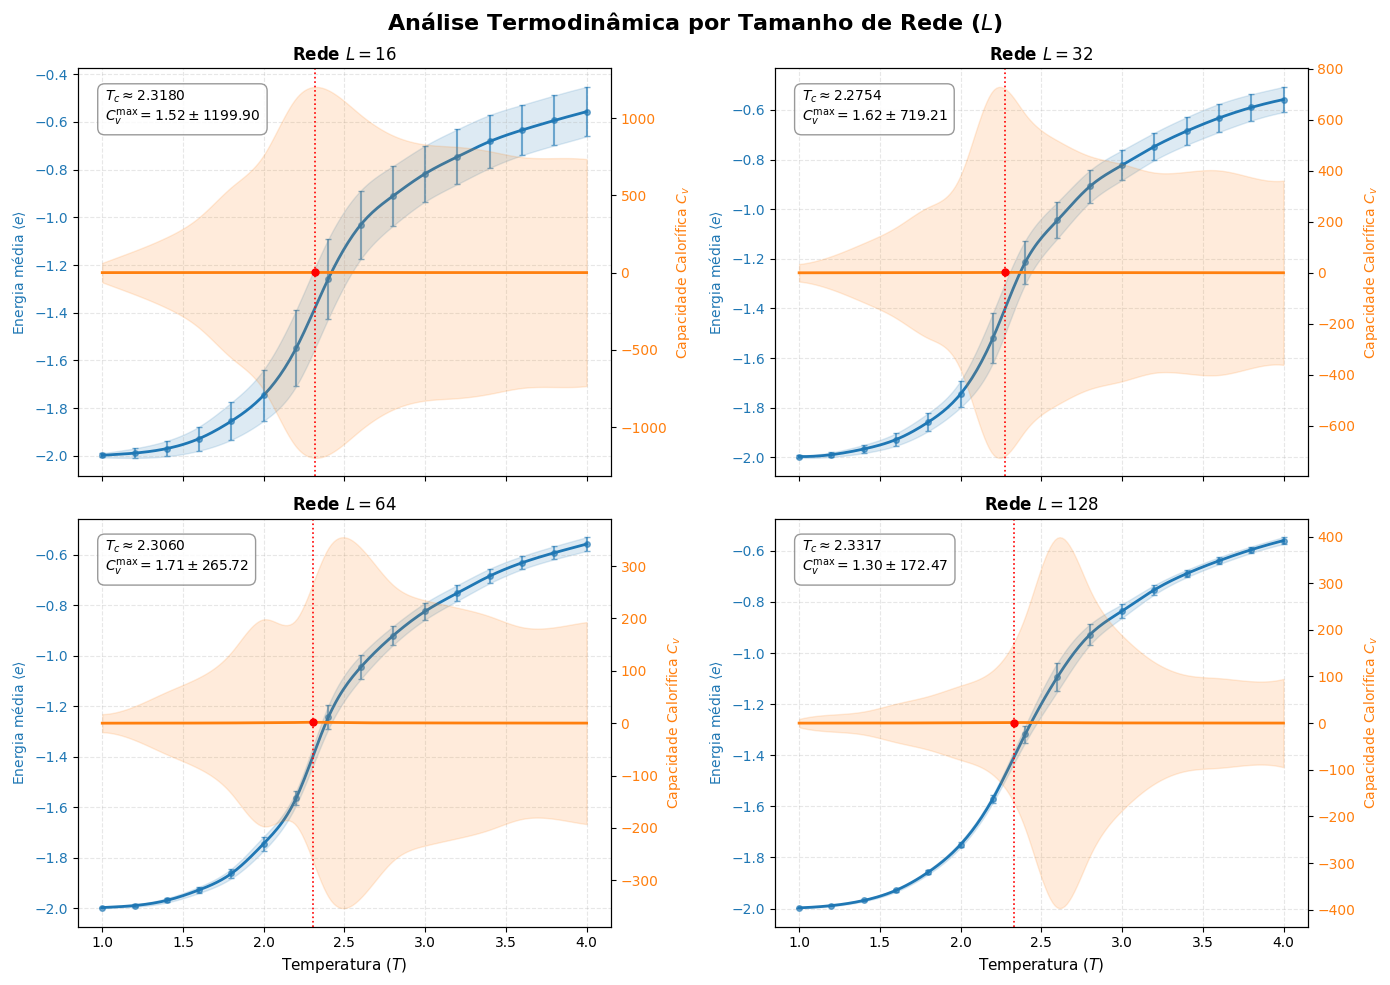

In [6]:
E_func     = RegularGridInterpolator(
    (L_values_2a, T_values_2a), e_mean,
    method="cubic", bounds_error=False, fill_value=None
)
E_std_func = RegularGridInterpolator(
    (L_values_2a, T_values_2a), e_std,
    method="cubic", bounds_error=False, fill_value=None
)

h_deriv = 1e-4   # passo da derivada central

def energy_temp(temp, L=128):
    temp = np.atleast_1d(temp)
    pontos = np.column_stack((np.full_like(temp, L), temp))
    return E_func(pontos)

def energy_std_temp(temp, L=128):
    temp = np.atleast_1d(temp)
    pontos = np.column_stack((np.full_like(temp, L), temp))
    return E_std_func(pontos)

def heat_cap_std(temp, L=128):
    return np.sqrt(energy_std_temp(temp + h_deriv, L)**2
                 + energy_std_temp(temp - h_deriv, L)**2) / (2 * h_deriv)

def derivada(f):
    def der(x):
        return (f(x + h_deriv) - f(x - h_deriv)) / (2 * h_deriv)
    return der

def biss(a, b, f):
    epsilon = h_deriv
    x_ = (a + b) / 2
    thres = 0
    if f(a) * f(b) > 0:
        raise Exception("No root inside.")
    while np.abs(f(x_)) > epsilon:
        x_ = (a + b) / 2
        if f(x_) * f(a) <= 0:
            b = x_
        else:
            a = x_
        thres += 1
        if thres == 100000:
            break
    return x_

X_smooth = np.linspace(1.0, 4.0, 200)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle("Análise Termodinâmica por Tamanho de Rede ($L$)",
             fontsize=16, fontweight='bold')

config_L = [
    {"L": 16,  "row": 0, "col": 0},
    {"L": 32,  "row": 0, "col": 1},
    {"L": 64,  "row": 1, "col": 0},
    {"L": 128, "row": 1, "col": 1},
]

for config in config_L:
    L_atual = config["L"]
    row, col = config["row"], config["col"]
    ax_en = axes[row, col]
    ax_cv = ax_en.twinx()
    iL = L_values_2a.index(L_atual)

    energy_local       = lambda t, L=L_atual: energy_temp(t, L=L)
    energy_std_local   = lambda t, L=L_atual: energy_std_temp(t, L=L)
    heat_cap_std_local = lambda t, L=L_atual: heat_cap_std(t, L=L)
    heat_cap_local     = derivada(energy_local)
    dc_local           = derivada(heat_cap_local)

    y_energy   = energy_local(X_smooth)
    err_energy = energy_std_local(X_smooth)
    y_cv       = heat_cap_local(X_smooth)
    err_cv     = heat_cap_std_local(X_smooth)

    try:
        c_atual      = biss(2.0, 2.5, dc_local)
        cv_no_pico   = heat_cap_local(c_atual)[0]
        erro_cv_pico = heat_cap_std_local(c_atual)[0]
    except Exception:
        c_atual = None

    ax_en.errorbar(T_values_2a, e_mean[iL], yerr=e_std[iL], fmt='o', color='C0',
                   capsize=2, ms=4, alpha=0.6, label="Dados MC")
    ax_en.plot(X_smooth, y_energy, color='C0', lw=2, label=r"$\langle e \rangle$ Cúbico")
    ax_en.fill_between(X_smooth, y_energy - err_energy, y_energy + err_energy,
                       color='C0', alpha=0.15)
    ax_en.set_ylabel(r"Energia média $\langle e \rangle$", color='C0')
    ax_en.tick_params(axis='y', labelcolor='C0')
    ax_en.grid(True, ls="--", alpha=0.3)

    ax_cv.plot(X_smooth, y_cv, color='C1', lw=2, label=r"$C_v$ (Derivada)")
    ax_cv.fill_between(X_smooth, y_cv - err_cv, y_cv + err_cv,
                       color='C1', alpha=0.15)
    ax_cv.set_ylabel(r"Capacidade Calorífica $C_v$", color='C1')
    ax_cv.tick_params(axis='y', labelcolor='C1')

    if c_atual is not None:
        ax_cv.axvline(c_atual, color="red", ls=":", lw=1.2)
        ax_cv.plot(c_atual, cv_no_pico, 'ro', ms=5)
        texto = (
            fr"$T_c \approx {c_atual:.4f}$" "\n"
            fr"$C_v^{{\max}} = {cv_no_pico:.2f} \pm {erro_cv_pico:.2f}$"
        )
        ax_en.text(0.05, 0.95, texto, transform=ax_en.transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                             alpha=0.8, edgecolor='gray'))

    ax_en.set_title(f"Rede $L = {L_atual}$", fontsize=12, fontweight='bold')
    if row == 1:
        ax_en.set_xlabel("Temperatura ($T$)", fontsize=11)

plt.tight_layout()
plt.show()


### 2(c)

Cálculo da capacidade calorífica pela base estatística do método de Metropolis-Hastings:

$$c = \frac{\langle E^2 \rangle - \langle E \rangle^2}{L^2 \, T^2}$$

Atenção: a equação usa a energia **total** $E$ (não a energia por spin $e = E/L^2$). Como
$E = L^2 \, e$, temos $\mathrm{Var}(E) = L^4 \, \mathrm{Var}(e)$, pelo que usar $e$ daria
um valor $L^2$ vezes mais pequeno.

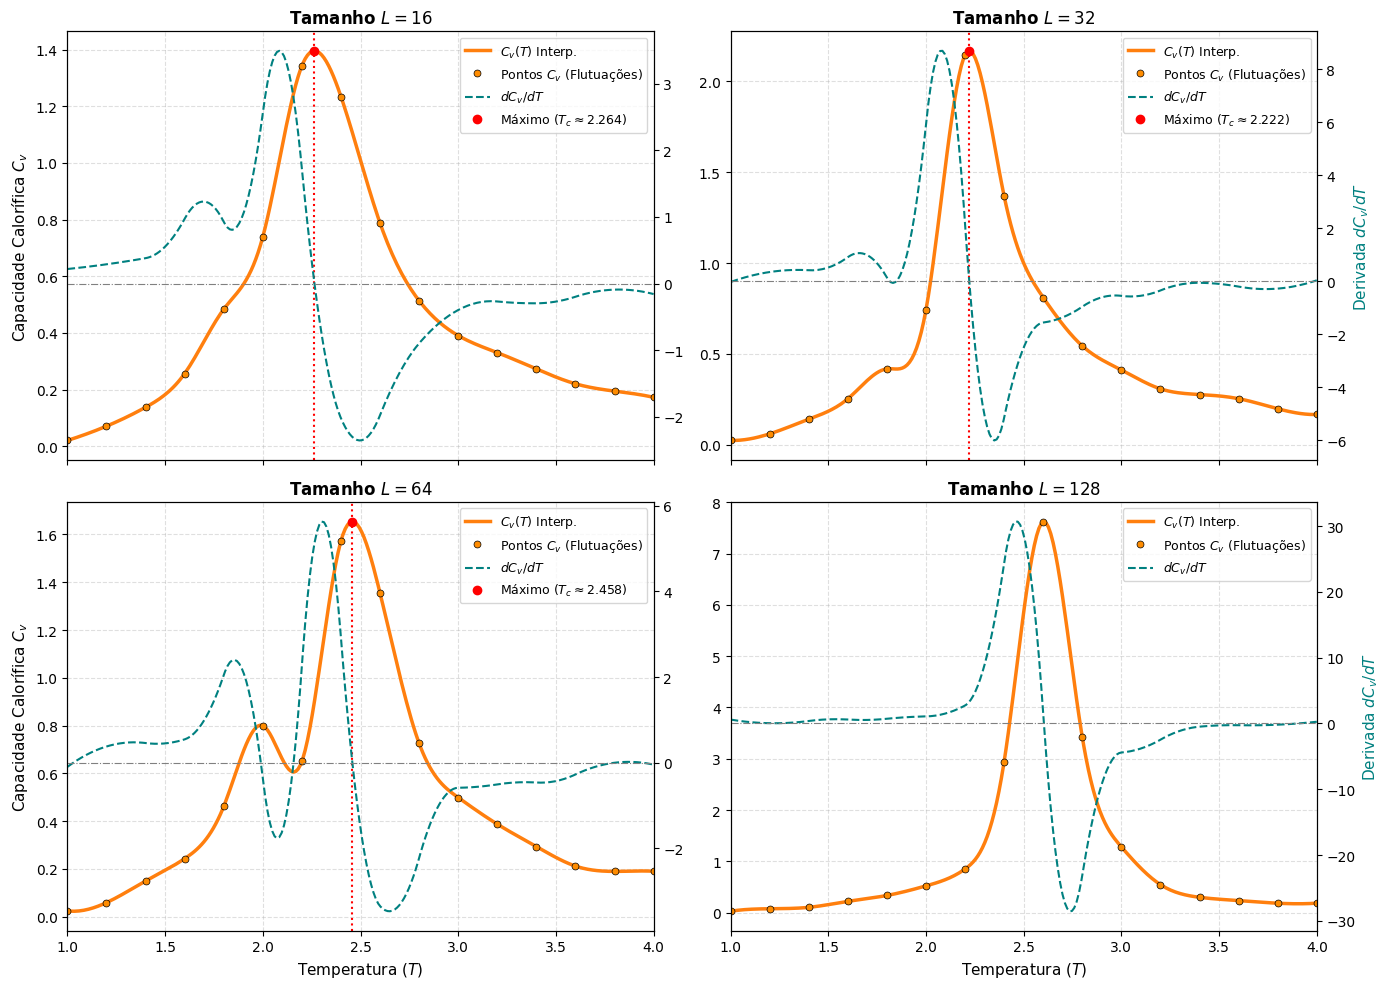

In [ ]:
def MetropolisHastings_heatCap(E_m, E_sq_m):
    heat_cap_points = np.zeros_like(E_m)
    for iL, L in enumerate(L_values_2a):
        for iT, T in enumerate(T_values_2a):
            heat_cap_points[iL, iT] = (E_sq_m[iL, iT] - E_m[iL, iT]**2) / (L**2 * T**2)
    return heat_cap_points

heat_cap_points = MetropolisHastings_heatCap(E_mean, E_sq_mean)

heat_cap_function = RegularGridInterpolator(
    (L_values_2a, T_values_2a), heat_cap_points,
    method="cubic", bounds_error=False, fill_value=None
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

X_smooth = np.linspace(1, 4, 250)

for idx, L_alvo in enumerate([16, 32, 64, 128]):
    ax = axes[idx]
    iL = L_values_2a.index(L_alvo)

    def heat_cap_function_1d_atual(temp, size=L_alvo):
        return heat_cap_function((size, temp))

    heat_cap_function_1d_der_atual = derivada(heat_cap_function_1d_atual)

    try:
        pico_atual = biss(2.2, 2.6, heat_cap_function_1d_der_atual)
    except Exception:
        pico_atual = None

    Y_smooth_cv  = np.array([float(heat_cap_function_1d_atual(t)) for t in X_smooth])
    Y_smooth_der = np.array([float(heat_cap_function_1d_der_atual(t)) for t in X_smooth])

    line1, = ax.plot(X_smooth, Y_smooth_cv, color='C1', lw=2.5, label="$C_v(T)$ Interp.")
    line2, = ax.plot(T_values_2a, heat_cap_points[iL], 'o', color='darkorange',
                     ms=5, mec='k', mew=0.5, label="Pontos $C_v$ (Flutuações)")

    ax_der = ax.twinx()
    line3, = ax_der.plot(X_smooth, Y_smooth_der, color='teal', lw=1.5, ls="--", label="$dC_v/dT$")
    ax_der.axhline(0, color='gray', lw=0.8, ls="-.")

    linhas = [line1, line2, line3]
    if pico_atual is not None:
        ax.axvline(x=pico_atual, color='red', linestyle=':', lw=1.5)
        cv_pico = float(heat_cap_function_1d_atual(pico_atual))
        line4, = ax.plot(pico_atual, cv_pico, 'ro', ms=6,
                         label=f"Máximo ($T_c \\approx {pico_atual:.3f}$)")
        linhas.append(line4)

    ax.set_title(f"Tamanho $L = {L_alvo}$", fontsize=12, fontweight='bold')
    ax.set_xlim(1.0, 4.0)
    ax.grid(True, ls="--", alpha=0.4)

    if idx in [2, 3]:
        ax.set_xlabel("Temperatura ($T$)", fontsize=11)
    if idx in [0, 2]:
        ax.set_ylabel(r"Capacidade Calorífica $C_v$", fontsize=11)
    if idx in [1, 3]:
        ax_der.set_ylabel(r"Derivada $dC_v/dT$", fontsize=11, color='teal')

    legendas = [l.get_label() for l in linhas]
    ax.legend(linhas, legendas, loc="upper right", fontsize=9, frameon=True, facecolor='white')

plt.tight_layout()
plt.show()
